# Aplicación de modelos de aprendizaje automático

### Support Vector Machine - SVM

cross_val_score
  Scores por fold : [0.9825 0.9825 0.9649 0.9474 0.9825 1.     0.9649 0.9107]
  Media           : 0.9669
  Desv. estándar  : 0.0259
              precision    recall  f1-score   support

           0       1.00      0.95      0.98        43
           1       0.97      1.00      0.99        71

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



Text(0.5, 1.0, 'Modelo 30D — Matriz de confusión')

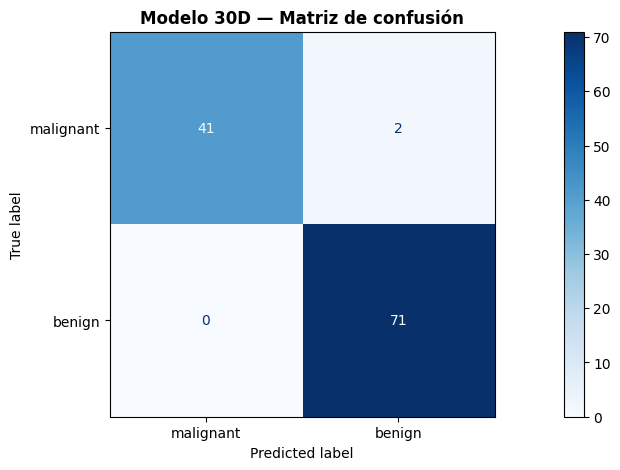

: 

In [ ]:
## Basic SVM structure (example from sklearn documentation) -------------------------------------------------------------
from sklearn import svm
X = [[0, 0], [1, 1]]   # Samples and features
y = [0, 1]
clf = svm.SVC() 
clf.fit(X, y)

## Application of SVM to the breast cancer dataset ----------------------------------------------------------------------
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.datasets import load_breast_cancer
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay


# Data loading
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)             # 30 features
y = pd.Series(data.target, name='target')                           # Binary output (0 o 1 - cáncer benigno o maligno)

#print(X.shape[1])
#print(X.columns.tolist())
#y = pd.DataFrame(data.target, columns=['target'])
#print(X)
#print(y)

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#X_t1 = pd.DataFrame(X_train, columns=data.feature_names)
#print(X_t1)
#X_t2 = pd.DataFrame(X_test, columns=data.feature_names)
#print(X_t2)

# Features scale (normalización) 
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#X_t1 = pd.DataFrame(X_train, columns=data.feature_names)
#print(X_t1)
#X_t2 = pd.DataFrame(X_test, columns=data.feature_names)
#print(X_t2)

# Initial tests
model = SVC(kernel='rbf', probability=True)
cv_scores = cross_val_score(model, X_train, y_train, cv=8, scoring='accuracy')

# Training the model
model.fit(X_train, y_train)

# Cross-validation results
print("cross_val_score")
print(f"  Scores por fold : {cv_scores.round(4)}")
print(f"  Media           : {cv_scores.mean():.4f}")
print(f"  Desv. estándar  : {cv_scores.std():.4f}")

# Evaluation
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

# Confusion matrix
fig, axes = plt.subplots(1, 1, figsize=(18, 5))
axes = [axes]
ConfusionMatrixDisplay.from_estimator(
    model, X_test, y_test,
    display_labels=data.target_names,
    cmap='Blues', ax=axes[0]
)
axes[0].set_title('Modelo 30D — Matriz de confusión', fontweight='bold')



### Random Forest Classifier - RF

## Implementación de metodologías de restricción (síntesis) y análisis variable sobre los modelos/arquitecturas

cross_val_score
  Scores por fold : [0.8947 0.9298 0.9474 0.9649 0.9123 0.9298 0.9474 0.8929]
  Media           : 0.9274
  Desv. estándar  : 0.0243


Text(0.5, 1.0, 'Modelo 30D — Matriz de confusión')

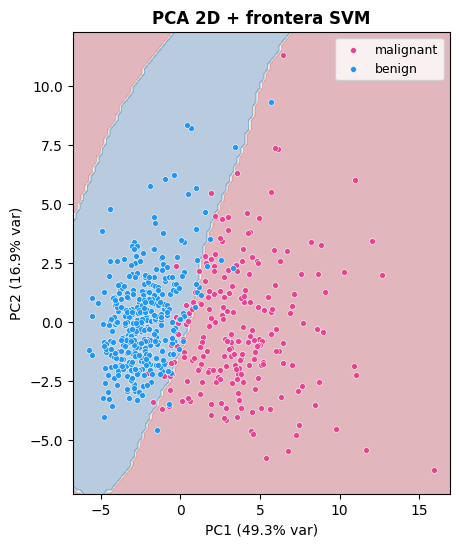

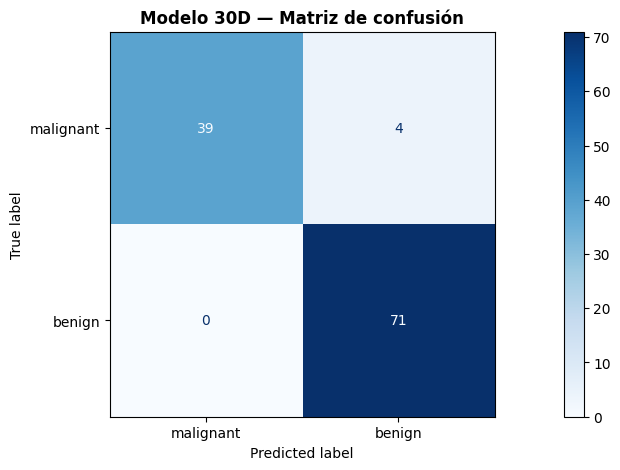

In [ ]:
# Test using PCA for dimensionality reduction from 30 features to 2, to be able to visualize the decision boundary of SVM in 2D.
X_all_sc = scaler.transform(X)

colors = ['#E84393', '#2196F3']  # maligno / benigno
labels = data.target_names        # ['malignant', 'benign']

fig = plt.figure(figsize=(18, 6))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

ax1 = fig.add_subplot(gs[0])
pca   = PCA(n_components=2, random_state=42)

X_pca_train  = pca.fit_transform(X_train)        # solo transform, 569×30 → 569×2
X_pca_all   = pca.transform(X_all_sc)        # solo transform, 569×30 → 569×2

# Entrena SVM en el espacio PCA para dibujar la frontera
svm_pca = SVC(kernel='rbf')

# Evaluation
cv_scores = cross_val_score(svm_pca, X_pca_train, y_train, cv=8, scoring='accuracy')

print("cross_val_score")
print(f"  Scores por fold : {cv_scores.round(4)}")
print(f"  Media           : {cv_scores.mean():.4f}")
print(f"  Desv. estándar  : {cv_scores.std():.4f}")

#print(classification_report(y_test, y_pred))

svm_pca.fit(X_pca_train, y_train)
y_pred = svm_pca.predict(X_pca_all)


DecisionBoundaryDisplay.from_estimator(
    svm_pca, X_pca_all, ax=ax1,
    response_method='predict',
    cmap=plt.cm.RdBu, alpha=0.3
)
for cls, col in enumerate(colors):
    mask = y == cls
    ax1.scatter(X_pca_all[mask, 0], X_pca_all[mask, 1],
                c=col, label=labels[cls], s=18, edgecolors='white', linewidths=0.4)

var = pca.explained_variance_ratio_ * 100
ax1.set_xlabel(f'PC1 ({var[0]:.1f}% var)', fontsize=10)
ax1.set_ylabel(f'PC2 ({var[1]:.1f}% var)', fontsize=10)
ax1.set_title('PCA 2D + frontera SVM', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)

fig, axes = plt.subplots(1, 1, figsize=(18, 5))
axes = [axes]
ConfusionMatrixDisplay.from_estimator(
    svm_pca, X_test, y_test,
    display_labels=data.target_names,
    cmap='Blues', ax=axes[0]
)
axes[0].set_title('Modelo 30D — Matriz de confusión', fontweight='bold')


In [30]:
# ── PCA: fit solo una vez, sobre train ESCALADO ───────────────────────────────
pca = PCA(n_components=2, random_state=42)

X_pca_train = pca.fit_transform(X_train_sc)  # fit aquí, 455×30 → 455×2
X_pca_all   = pca.transform(X_all_sc)        # solo transform, 569×30 → 569×2

# svm_pca recibe directamente X_pca_train, ya tiene 2 features
svm_pca = SVC(kernel='rbf')
svm_pca.fit(X_pca_train, y_train)            # 455×2 ✓

# visualización
DecisionBoundaryDisplay.from_estimator(
    svm_pca, X_pca_all, ax=ax1,
    response_method='predict',
    cmap=plt.cm.RdBu, alpha=0.3
)